In [1]:
import pandas as pd
import sqlite3

In [2]:
conn = sqlite3.connect('roulette_results.db')

df = pd.read_sql('SELECT * FROM roulette_simulations', conn)

conn.close()

#pd.options.display.float_format = '{:.3f}'.format

**Масштаб симуляции:** Общий объем смоделированного игрового процесса составляет 100 000 итераций (вращений). Для корректного статистического анализа массив был распределен на 1 000 независимых сессий (игроков) по 100 раундов в каждой. В базе данных SQLite3 зафиксированы финальные агрегированные исходы для 1 000 конечных бюджетов, что исключило избыточность данных и сформировало репрезентативную выборку для оценки волатильности по методу Монте-Карло.


Создание нового столбца. В котором будет известна, какую долю занимает ставка относительно бюджета. 

In [4]:
df['bid share'] = df['bet_size'] / df['initial_balance']

Разделяем датафреймы по ставке 

In [5]:
bet_10 = df[df['bet_size'] == 10]
bet_50 = df[df['bet_size'] == 50]
bet_100 = df[df['bet_size'] == 100]

### Средние значения даланса для ставки 10 (1% от бюджета), для нескольких игр 

In [6]:
groupby_10 = bet_10.groupby('label')[['balance_new','games_count','bid share']].mean().sort_values(by='balance_new', ascending=False)
groupby_10

,balance_new,games_count,bid share
label,,,
6 чисел,987.54,100.0,0.01
2 чисел,981.54,100.0,0.01
4 чисел,974.52,100.0,0.01
18 чисел,973.28,100.0,0.01
12 чисел,971.91,100.0,0.01
1 чисел,966.24,100.0,0.01
3 чисел,964.44,100.0,0.01


### 🎰 Парадокс долгой дистанции и математика House Edge

На дистанции в 100 000 вращений (итераций) ни одна игровая сессия со стороны пользователя математически не способна демонстрировать чистую прибыль. Данный феномен полностью обоснован архитектурой теории игр:

1. **Концепция House Edge (Преимущество заведения):** За счет внедрения сектора «зеро» (0) казино сдвигает истинную вероятность исходов в пользу заведения (вероятность проиграть всегда выше). Эта микроскопическая разница формирует гарантированную маржу заведения (2.7% для европейской рулетки).
2. **Закон больших чисел (LLN):** На коротком отрезке в 10–50 вращений игрок может находиться в плюсе из-за дисперсии (фактора случайной удачи). Однако на дистанции в 100 000 итераций закон больших чисел полностью сглаживает случайные отклонения. Доходность игрока строго и неотвратимо приближается к теоретическому отрицательному математическому ожиданию.
3. **Бизнес-механика удержания (Retention):** Архитектура игры спроектирована так, чтобы поддерживать идеальный баланс: преимущество казино работает незаметно для обывателя, позволяя игрокам периодически выигрывать на коротких дистанциях. Это создает мощное психологическое подкрепление, сохраняет иллюзию контроля и поддерживает мотивацию продолжать игру, в то время как на макро-уровне казино получает абсолютно стабильный и предсказуемый доход. 
4. **Научное обоснование удержания (Retention):** Данный механизм основан на нейробиологических особенностях работы дофаминергической системы мозга. Исследования показывают постепенное нарастание активности нейронов в период между стимулом и возможным моментом получения награды. Продуктивный пик этой активности достигается при вероятности исхода Р = 0.5 (то есть в точке наивысшей неопределенности и риска) (PMID: 12649484). Именно за счет этого биологического механизма (максимального дофаминового отклика на равные шансы) и удерживается вся индустрия азартных игр.


**Стандартное отклонение для группы 1% от бюджета**

In [7]:
bet_10.groupby('label')[['balance_new','games_count']].std().sort_values(by='balance_new', ascending=False)

,balance_new,games_count
label,,
1 чисел,597.523972,0.0
2 чисел,405.654266,0.0
3 чисел,324.687093,0.0
4 чисел,281.690112,0.0
6 чисел,219.617349,0.0
12 чисел,141.157988,0.0
18 чисел,100.861363,0.0


### ⚖️ Минимизация волатильности через низкое стандартное отклонение

Стратегия, сочетающая ставку на 18 чисел (равные шансы) с ограничением объема в 1% от общего бюджета, математически является наиболее безопасной моделью управления капиталом. Данный эффект обусловлен минимизацией стандартного отклонения и контролем над дисперсией:

1. **Минимизация стандартного отклонения:** Ставка на 18 чисел обеспечивает максимальную вероятность успеха в отдельном раунде (48.65% в европейской рулетке). В отличие от высокорискованных ставок на конкретные числа (где выигрыши редки, но крупны), данная стратегия генерирует частые, но небольшие выплаты. Это сглаживает кривую баланса и удерживает показатель стандартного отклонения на минимальном уровне, защищая бюджет от резких просадок.
2. **Увеличение «времени жизни» клиента (LTV и Time Spent):** Ограничение ставки в 1% в сочетании с низкой волатильностью исходов позволяет игроку совершить максимальное количество итераций на дистанции. Для пользователя это означает контролируемый игровой процесс с минимальным риском случайного вылета на короткой дистанции. 
3. **Бизнес-контекст для казино:** Для заведения такая модель поведения игрока означает стабильное, прогнозируемое и плавное изъятие маржи (House Edge) без риска получить внезапную крупную выплату по обязательствам. Длинная сессия лояльного клиента максимизирует его общую ценность (LifeTime Value) для платформы за счет стабильного объема оборота ставок.


### Средние значения баланса для ставки 50 (5% от бюджета), для нескольких игр 

In [8]:
groupby_50 = bet_50.groupby('label')[['balance_new','games_count','bid share']].mean().sort_values(by='balance_new', ascending=False)
groupby_50

,balance_new,games_count,bid share
label,,,
3 чисел,944.6,68.452,0.05
1 чисел,911.8,47.052,0.05
4 чисел,899.8,73.095,0.05
6 чисел,863.5,80.742,0.05
12 чисел,857.4,93.242,0.05
18 чисел,834.5,98.220,0.05
2 чисел,827.4,58.712,0.05


### 📉 Агрессивный денежный-менеджмент и риск разорения (Risk of Ruin)

Увеличение размера одной ставки до 5% от общего бюджета критически снижает стабильность игровой сессии. В условиях отрицательного математического ожидания даже кратковременные серии выигрышей математически неспособны компенсировать высокую скорость выгорания капитала при проигрышах.

1. **Риск быстрого разорения:** В гемблинг-аналитике ставка в 5% считается крайне агрессивной. При такой стратегии игроку достаточно поймать стандартную для случайных распределений серию всего из 20 неудачных вращений подряд, чтобы полностью обнулить свой баланс.
2. **Асимметрия выгоды для казино:** Для пользователя такая динамика означает гарантированное сокращение времени игровой сессии (Time Spent) и быструю потерю средств. Однако для казино данный сценарий является коммерчески выгодным. Ускоренное банкротство игрока минимизирует операционные риски заведения на выдачу крупных случайных джекпотов и увеличивает пропускную способность (вместимость) платформы. 
3. **Оптимизация трафика:** Быстрое освобождение игрового места (или серверной сессии) позволяет казино эффективнее утилизировать входящий трафик, вовлекая новых пользователей и максимизируя совокупную оборачиваемость средств за единицу времени.


**Стандартное отклонение для группы 5% от бюджета**

In [24]:
bet_50.groupby('label')[['balance_new','games_count']].std().sort_values(by='balance_new', ascending=False)

,balance_new,games_count
label,,
1 чисел,2043.888020,34.908106
2 чисел,1452.121861,34.561012
3 чисел,1332.376098,33.109938
4 чисел,1189.382020,31.403442
6 чисел,967.881472,27.303166
12 чисел,655.091127,16.207162
18 чисел,476.830281,7.502525


### 📊 Рост стандартного отклонения как маркер критической нестабильности

Резкое увеличение показателя стандартного отклонения при ставке в 5% от бюджета математически подтверждает критическую нестабильность и высокую волатильность игровой сессии. 

1. **Амплитуда колебаний банкролла:** Высокое стандартное отклонение означает, что значения текущего баланса игрока начинают совершать огромные хаотичные скачки вверх и вниз относительно среднего ожидания. В условиях отрицательного математического ожидания такая раскачка дисперсии делает игровой процесс абсолютно непредсказуемым на короткой дистанции и разрушительным на длинной.
2. **Математическая ловушка дисперсии:** При агрессивной ставке в 5% череда даже из нескольких неудачных раундов подряд (что является нормой для случайных распределений) наносит невосполнимый ущерб общему банку. Высокое стандартное отклонение наглядно иллюстрирует, что редкие пиковые выигрыши просто не успевают компенсировать стремительную скорость выгорания капитала.
3. **Бизнес-интерпретация риска:** Для казино этот всплеск стандартного отклонения означает переход игры в фазу повышенного риска (High Volatility). С одной стороны, это гарантирует ускоренный вылет и банкротство большинства нерациональных игроков. С другой стороны, на сверхкоротких дистанциях это создает риск временных крупных выплат со стороны заведения, что требует от оператора наличия солидного финансового буфера (ликвидности) для сглаживания этих дисперсионных скачков.


**Средние значения даланса для ставки 100 (10% от бюджета), для нескольких игр** 

In [10]:
groupby_100 = bet_100.groupby('label')[['balance_new','games_count','bid share']].mean().sort_values(by='balance_new', ascending=False) 
# со ставкой 10% от бюджета у меня больше нулей 
# в бюджете чем дохода 
groupby_100

,balance_new,games_count,bid share
label,,,
2 чисел,968.4,34.390,0.1
1 чисел,948.6,27.298,0.1
3 чисел,885.6,40.072,0.1
4 чисел,876.6,45.964,0.1
18 чисел,839.2,82.924,0.1
6 чисел,825.0,52.900,0.1
12 чисел,783.9,69.667,0.1


Стандартное отклонение для группы 10% от бюджета 

In [11]:
bet_100.groupby('label')[['balance_new','games_count']].std().sort_values(by='balance_new', ascending=False)

,balance_new,games_count
label,,
1 чисел,2982.799882,32.463596
2 чисел,2481.426791,35.294782
3 чисел,2086.025921,36.602494
4 чисел,1812.864837,36.830493
6 чисел,1546.443173,36.695730
12 чисел,1054.942507,33.622799
18 чисел,852.097077,26.914952


### ⚠️ Точка критического выгорания и обвал длины сессии (Session Length)

Переход на сверхагрессивную стратегию со ставкой в 10% от бюджета приводит к окончательной дестабилизации системы. Кривая капитала демонстрирует экстремальный рост дисперсии на фоне стремительного падения среднего дохода и критического сокращения времени жизни банкролла.

1. **Обвальное падение длины сессии (Session Length):** Если при консервативной ставке в 1% система стабильно позволяет гарантированно проводить длинные сессии от 100 игр подряд, то при ставке в 10% средняя продолжительность сессии падает. Математическая вероятность поймать короткую серию неудач полностью уничтожает банкролл за считанные минуты.
2. **Экстремальный разброс и хаос (Дисперсия):** Рост дисперсии при 10% ставке показывает, что игра полностью теряет признаки управляемого процесса. Баланс совершает колоссальные хаотичные скачки, однако из-за высокой стоимости каждого входа любая кратковременная просадка мгновенно становится фатальной, не оставляя капиталу запаса прочности для восстановления.
3. **Бизнес-эффект: Выгорание вовлеченности против маржинальности:** Для казино такая модель поведения клиента означает максимальную скорость изъятия банкролла, но несет в себе серьезные продуктовые риски. Сверхкороткая сессия критически снижает эмоциональную вовлеченность игрока. Пользователь не успевает погрузиться в игровой процесс, сталкивается с мгновенным негативным опытом, что катастрофически роняет метрику Retention.


### Визуальное дополнение, по играм из prelude.

**Ставка 10** (1%) на 18 чисел

In [12]:
for_hist = bet_10[bet_10['label'] == '18 чисел']
for_hist[['balance_new', 'wins', 'losses']].describe()

,balance_new,wins,losses
count,1000.000000,1000.000000,1000.000000
mean,973.280000,48.664000,51.336000
std,100.861363,5.043068,5.043068
min,680.000000,34.000000,37.000000
25%,900.000000,45.000000,48.000000
50%,980.000000,49.000000,51.000000
75%,1040.000000,52.000000,55.000000
max,1260.000000,63.000000,66.000000


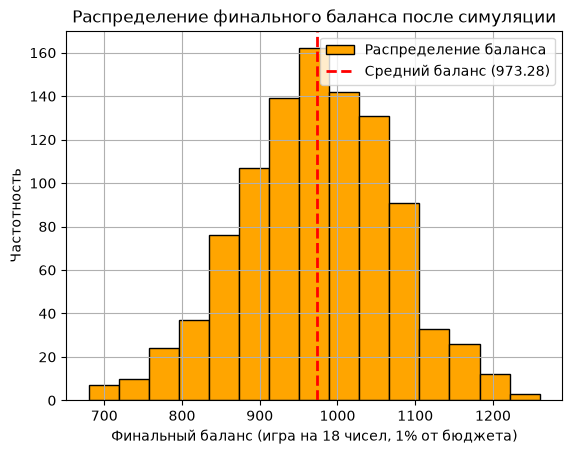

In [18]:
import matplotlib.pyplot as plt

# 1. Считаем среднее значение
mean_balance = for_hist['balance_new'].mean()

# 2. Строим гистограмму с раздельными столбцами и ярлыком для легенды
for_hist['balance_new'].hist(bins=15, edgecolor='black', color='orange', label='Распределение баланса')

# 3. Рисуем вертикальную линию среднего значения
plt.axvline(mean_balance, color='red', linestyle='--', linewidth=2, label=f'Средний баланс ({mean_balance:.2f})')

# 4. Настраиваем название, оси и выводим легенду
plt.title('Распределение финального баланса после симуляции')
plt.xlabel('Финальный баланс (игра на 18 чисел, 1% от бюджета)')
plt.ylabel('Частотность')
plt.legend()

plt.show()



#### ⚖️ Ставка на 18 чисел (Равные шансы / Минимальная волатильность)
* **Особенность графика:** Распределение имеет форму симметричного и плотного колокола Гаусса с минимальным стандартным отклонением. 
* **Ловушка восприятия:** Визуально график создает опасную иллюзию «гарантированного заработка» из-за высокой частоты побед в отдельных раундах и плавности хода кривой. 
* **Математическая реальность:** В этом и кроется главный парадокс House Edge. Незначительное, но неотвратимое смещение среднего значения распределения в отрицательную зону (влево) работает незаметно для игрока. Низкая волатильность маскирует постоянный микро-проигрыш, удерживая пользователя в игре (высокий Retention) и стабильно изымая его банкролл в пользу казино на долгой дистанции.


Ставка на 1 число

In [33]:
for_hist_n1 = bet_10[bet_10['label'] == '1 чисел']
for_hist_n1[['balance_new', 'wins', 'losses']].describe()

,balance_new,wins,losses
count,1000.000000,1000.000000,1000.000000
mean,966.240000,2.684000,97.316000
std,597.523972,1.659789,1.659789
min,0.000000,0.000000,90.000000
25%,360.000000,1.000000,96.000000
50%,1080.000000,3.000000,97.000000
75%,1440.000000,4.000000,99.000000
max,3600.000000,10.000000,100.000000


Медианная вызывает вопросы, посмотрим моду. 

In [34]:
for_hist_n1[['balance_new', 'wins', 'losses']].mode()

,balance_new,wins,losses
0,720.0,2,98


#### 🎯 Ставка на 1 число (Высокая волатильность)
* **Математическая ловушка описательной статистики:** Симуляция выявила классическое противоречие между метриками центральной тенденции. Медиана выборки составляет 1080, что создает ложную иллюзию прибыльности игры. Однако из-за экстремальной асимметрии (тяжелого правого хвоста) медиана здесь не отражает реальность.
* **Мода:** Мода распределения равна 720 (самый частый исход — всего 2 выигрыша за 100 раундов). Именно мода наглядно доказывает, что абсолютное большинство игроков сталкивается с крупным убытком в 28% от банкролла. Высокая волатильность маскирует реальный риск, заставляя доверять редким крупным выбросам на графике.
* **Особенности:** Также стоит учитывать, что выборка состоит из 1 000 измерений бюджета по 100 игр. Для изменения медианы достаточно нескольких новых значений в диапазоне от 0 до 50-го процентиля, чтобы сместить индекс медианы ближе к среднему значению.




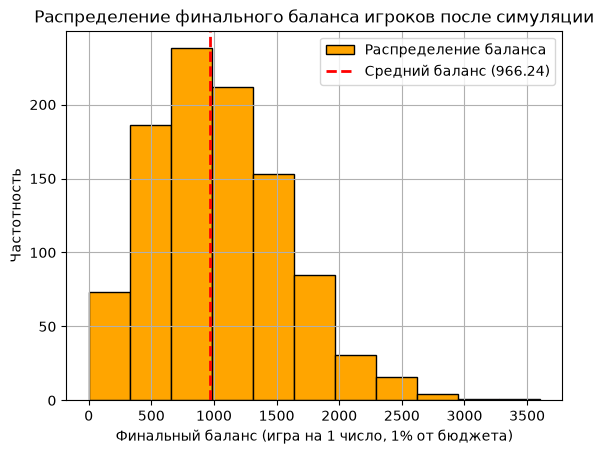

In [32]:
# 1. Считаем среднее значение
mean_balance_n1 = for_hist_n1['balance_new'].mean()

# 2. Строим гистограмму с раздельными столбцами и ярлыком для легенды
for_hist_n1['balance_new'].hist(bins=11, edgecolor='black', color='orange', label='Распределение баланса')

# 3. Рисуем вертикальную линию среднего значения
plt.axvline(mean_balance_n1, color='red', linestyle='--', linewidth=2, label=f'Средний баланс ({mean_balance_n1:.2f})')

# 4. Настраиваем название, оси и выводим легенду
plt.title('Распределение финального баланса игроков после симуляции')
plt.xlabel('Финальный баланс (игра на 1 число, 1% от бюджета)')
plt.ylabel('Частотность')
plt.legend()

plt.show()

#### 💼 Бизнес-вердикт 

Наличие тяжелого правого хвоста генерирует регулярные «истории успеха» (крупные случайные выплаты везунчикам), которые активно тиражируются, снижают когнитивную нагрузку и усыпляют бдительность массового потребителя. Для казино этот механизм является главным драйвером удержания аудитории.  

При этом общая математика House Edge (за счет сектора зеро) остается непоколебимой: редкие джекпоты из правого хвоста заложены в общую волатильность системы и полностью компенсируются тотальным, плавным и прогнозируемым изъятием банкроллов у основной массы клиентов в левой части распределения.
